# 01 — Data Collection

## Raw data

The raw Reddit data file is not stored in this repository. Download it from Google Drive (read-only link, no sign-in required):

**[Google Drive — raw data file](https://drive.google.com/file/d/1TBeqUEltZdwfWYRdvzUHOk3gCinRE6u6/view?usp=sharing)**

Place the file under `data/` as follows:
```
data/
└── coded/
    └── 20250210005631_posts.zip
```

> **Skipping this notebook?** If you only want to re-run the analysis, start from
> `02_feature_engineering.ipynb` — the output of this notebook is already saved in
> `results/comments_df.csv.zip`.


In [ ]:
# Local path config — adjust if your data lives elsewhere
import os
DATA_DIR  = os.path.abspath('../data')
RESULTS_DIR = os.path.abspath('../results')
print('DATA_DIR :', DATA_DIR)
print('RESULTS_DIR:', RESULTS_DIR)


# Analysis of Persuasion Characteristics in Argumentative Content in Discussion Groups
Text Mining Project by **Odeliah Movadat** and **Dikla Vilge**

# １. Introduction

## 1.1. The CMV Forum on Reddit and the "Delta" Concept

[Change My View](https://www.reddit.com/r/changemyview/) (CMV) is a popular subreddit on Reddit where users engage in structured debates with the goal of persuading others to reconsider their viewpoints. Unlike typical internet arguments, CMV encourages respectful discourse, requiring users to provide well-reasoned arguments and evidence. A core feature of CMV is the "delta" system: if a user successfully changes another participant’s mind, the persuaded user awards them a "delta" symbol (∆). This delta serves as an indicator of a convincing argument, making CMV a unique platform for studying persuasion in online discussions. The structured format of the forum, combined with the delta-based feedback, provides a valuable dataset for analyzing what makes an argument compelling.

## 1.2. Goals of the Work

The main objective of this project is to explore the properties that differentiate persuasive arguments from non-persuasive ones. Specifically, we aim to:

* Identify textual properties that contribute to persuasion.

* Analyze the differences between convincing and non-convincing arguments.

* Develop a machine learning model capable of predicting whether an argument is convincing based on its linguistic and structural features.
By achieving these goals, we aim to gain deeper insights into the mechanics of persuasion and contribute to the broader field of computational argumentation analysis.

## 1.3. Motivation

Previous research has leveraged CMV discussions to study persuasion, but earlier studies were often limited by the analytical methods available at the time. With recent advancements in natural language processing (NLP) and machine learning, we now have the tools to extract more nuanced insights from text data. By applying modern text mining techniques, such as transformer-based language models and sophisticated feature engineering methods, we can potentially improve upon previous results and enhance our understanding of what makes an argument compelling. This work has practical applications in areas such as automated debate analysis, content moderation, and persuasive writing assistance.

## 1.4. Process Overview

The research follows a structured methodology to analyze persuasive arguments effectively:

1. **Data Collection & Preparation:** We compile a dataset from CMV discussions, ensuring that each row includes the argument (comment), the context in which it was made, and whether it was awarded a delta (indicating it was convincing).

2. **Feature Engineering:** We identify and extract key textual properties that may influence persuasion, such as sentiment, readability, rhetorical devices, and linguistic complexity.

3. **Model Development & Evaluation:** The extracted features are fed into a machine learning model, which is trained to predict whether an argument will receive a delta. The model's performance is then evaluated using standard classification metrics to determine its effectiveness.

By following this approach, we aim to contribute valuable insights into the nature of persuasive language and refine techniques for automatic persuasion detection.



# ２. Collecting Raw Data

## 2.1 The Downloaded Data


Raw JSON files downloaded by `00_data_download.ipynb` are stored in `data/`. The annotation step below runs automatically on any file that does not yet have a coded counterpart in `data/coded/`. Already-coded files are skipped.


### Annotation pipeline

For each raw JSON in `data/`, this step applies topic classification, delta labeling, and evidence detection. Keyword files are loaded from `data/topics/` and `data/evidence-language/`; if absent, those two annotation types are skipped and only delta labeling runs.


In [ ]:
# Based on discussion_analysis.py by J. Hunter Priniski & Zachary Horne
# https://github.com/jpriniski/CMV
import itertools, string, re
from bs4 import BeautifulSoup
from nltk.stem.snowball import SnowballStemmer

_stemmer = SnowballStemmer('english')

def _read_terms(path):
    with open(path) as f:
        lines = [l.strip() for l in f.read().split('\n') if l.strip()]
    stemmed = [[_stemmer.stem(t) for t in line.split()] for line in lines]
    stemmed.sort()
    return list(s for s, _ in itertools.groupby(stemmed))

def _prepare(text):
    table = str.maketrans("", "", string.punctuation)
    tokens = [_stemmer.stem(w) for w in text.lower().translate(table).split()]
    tokens.sort()
    return list(t for t, _ in itertools.groupby(tokens))

def _get_ngrams(text, n):
    if n == 1:
        return [[w] for w in text]
    return [list(g) for g in zip(*[text[i:] for i in range(n)])]

def _match(text, terms):
    largest = max(len(x) for x in terms)
    for i in range(1, largest + 1):
        grams = _get_ngrams(text, i)
        for term in terms:
            if term in grams:
                return True
    return False

def _classify_text(text, categories):
    prepared = _prepare(text)
    result = {}
    for key, terms in categories.items():
        result[key] = {'match': _match(prepared, terms)}
        if 'number' in key.lower() and any(c.isdigit() for c in text):
            result[key]['match'] = True
    return result

def _get_parent(comments, current):
    parent_id = current['parent_id']
    for c in comments:
        if parent_id in c.get('name', ''):
            return c
    return None

def _award_deltas(comments):
    delta_ids = {
        c['id'] for c in comments
        if c.get('author') and 'DeltaBot' in c['author']
        and 'confirmed: 1 delta awarded to' in c.get('body', '').lower()
    }
    for c in comments:
        c['Delta'] = {'count': 0, 'from': {}}
    for c in comments:
        if c['id'] in delta_ids:
            delta_sig = _get_parent(comments, c)
            if delta_sig is None:
                continue
            dac = _get_parent(comments, delta_sig)
            if dac is None:
                continue
            dac['Delta']['count'] += 1
            if 'author' in delta_sig:
                dac['Delta']['from'][delta_sig['author']] = delta_sig.get('body', '')

def _get_links(comments):
    for c in comments:
        if 'body_html' not in c:
            continue
        soup = BeautifulSoup(c['body_html'], 'html.parser')
        c['links'] = [str(a) for a in soup.findAll('a', attrs={'href': re.compile("^https?://")})]


In [ ]:
TOPICS_DIR   = os.path.abspath('../data/topics')
EVIDENCE_DIR = os.path.abspath('../data/evidence-language')
CODED_DIR    = os.path.join(DATA_DIR, 'coded')

def _load_categories(base_dir, names):
    if not os.path.isdir(base_dir):
        return None
    cats = {n: _read_terms(os.path.join(base_dir, f'{n}.txt'))
            for n in names if os.path.exists(os.path.join(base_dir, f'{n}.txt'))}
    return cats or None

topics   = _load_categories(TOPICS_DIR,   ['gender', 'hot_topics', 'lgbt', 'moral', 'politics', 'race', 'religion'])
evidence = _load_categories(EVIDENCE_DIR, ['data', 'economics', 'evidence', 'numbers', 'stats', 'values', 'explanations'])

os.makedirs(CODED_DIR, exist_ok=True)
annotated = []

for fname in sorted(os.listdir(DATA_DIR)):
    if not fname.endswith('.json'):
        continue
    coded_path = os.path.join(CODED_DIR, fname)
    if os.path.exists(coded_path):
        print(f'Already coded — skipping {fname}')
        continue
    with open(os.path.join(DATA_DIR, fname)) as f:
        data = json.load(f)
    for post in data:
        if not post.get('selftext'):
            continue
        if topics:
            post['topic'] = _classify_text(post['title'] + ' ' + post['selftext'], topics)
        if not post.get('_comments'):
            continue
        _get_links(post['_comments'])
        _award_deltas(post['_comments'])
        if evidence:
            for comment in post['_comments']:
                if 'body' in comment:
                    comment['evidence_use'] = _classify_text(comment['body'], evidence)
    with open(coded_path, 'w') as f:
        json.dump(data, f)
    print(f'Annotated → {coded_path}')
    annotated.append(fname)

if not annotated:
    print('No new files to annotate.')
if not topics:
    print(f'\nNote: topic/evidence keyword files not found at {TOPICS_DIR}/')
    print('Topic and evidence classification were skipped.')
    print('To enable, add the .txt files from https://github.com/jpriniski/CMV/tree/master/Study2')


In [ ]:
coded_data_path = "../data/coded/20250210005631_posts.zip"


In [ ]:
import zipfile
import pandas as pd
import json

with zipfile.ZipFile(coded_data_path) as zf:
    with zf.open(zf.namelist()[0]) as f:
        data = json.load(f)

df = pd.DataFrame(data)
print(f'{len(df)} posts loaded')


In [ ]:
print(len(df))

This is our dataset — 425 posts from the r/changemyview subreddit.

# ３. Understanding Raw Data

In [ ]:
df.columns

Let's try to "feel" what's inside some of the columns:

In [ ]:
df.iloc[0]['_comments'][0]

In [ ]:
df.iloc[0]['_comments'][0]['Delta']

In [ ]:
df.iloc[0]['_comments'][0]['body']


In [ ]:
df.iloc[0]['_comments'][0]['evidence_use']

In [ ]:
thread = df.iloc[0]['_comments']
comments = {com['id']: com for com in thread}
comments

In [ ]:
# 1 comment example:
comment_id = 'dtsmms8'  # selected randomly manually from the list above
parent_id = comments[comment_id]['parent_id']
parent_id

In [ ]:
for comment in comments.values():
  comment['parent_id_edited'] = comment['parent_id'].split('_')[1]

In [ ]:
print("The parent comment:")
print(comments[parent_id.split('_')[1]]['body'])
print()
print("The original comment:")
print(comments[comment_id]['body'])

In [ ]:
df.iloc[0]['id']

In [ ]:
df.iloc[0]['title']

In [ ]:
print(df.iloc[0]['selftext'].replace('\n', '\n'))

print("\n--- Authored by: " + df.iloc[0]['author'])


In [ ]:
# print a few examples for a comment that is a child of the original body
counter = 0
for comment in comments.values():
  if comment['parent_id_edited'] == df.iloc[0]['id']:
    print(comment['body'])
    print("\n--- Authored by: " + comment['author'])
    print("-----------------------")
    counter += 1
    if counter == 3:
      break

# ４. Creating the Comments DataSet

The raw data contains a row for every thread. We want to find the convincing comments and create for each of them a row that contains:
* The original post
* The convincing comment
* The context: all the previous comments in the thread that were authored by the same same author as the convincing comment
* The class = is_convincing = true
* The convincing comment id (for debugging purposes)

We will throw away any additional comments that come AFTER the convincing comment in the thead.

Then, for every "leaf" in the tree of comments, we will create an appropriate row with the same structure, and set is_convincing = false. Unless the leaf is a parent of a (removed) convincing comment.

**Note:** we chose to define the context of the comment as only the comments by the same author. We could use all the comments in the thread instead. There are pros and cons for each approach.

If we only use the comments by the same author, we may lose other comments by different authors that represent the same "side" of the argument as the author of the convincing comment, and these additional commnets may affect the overall persuasion.

However, using only the same author guarentees that the "context" will have the same writing style, sentiment and opinion as the convincing comment. The style and sentiment are important for the features that we will later create from the data.

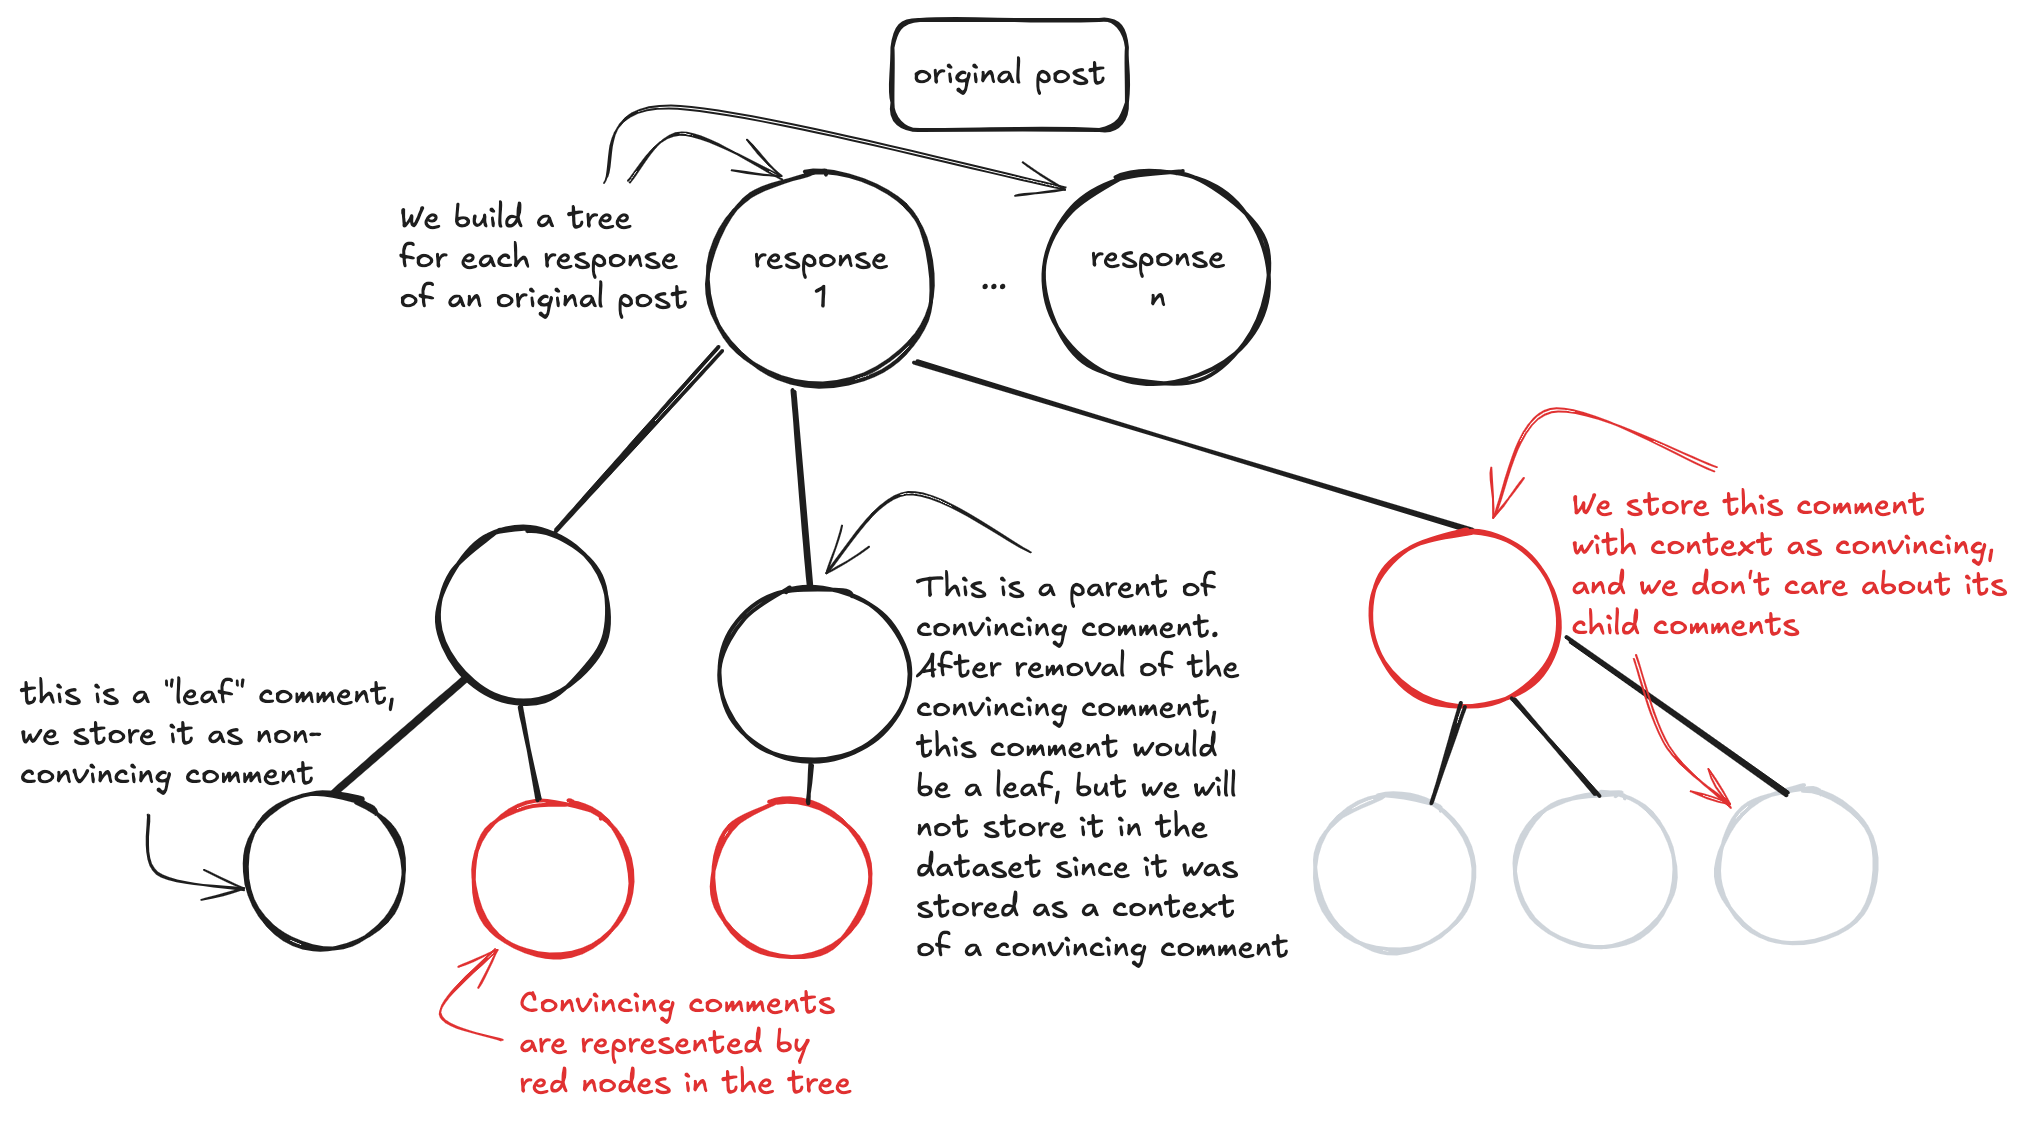

First, we will create the code to build the tree. As an example, we will work on an arbitrary row in the dataframe. Later we will use this code on all the rows in the df.

In [ ]:

def add_children(comment, all_comments):
    child_comments = [com for com in all_comments if com['parent_id_edited'] == comment['id']]
    if not child_comments:
        return

    for child_comment in child_comments:
      child_comment['children'] = []
      comment['children'].append(child_comment)
      add_children(child_comment, all_comments)

def build_comment_tree(comments, original_post_id):
    comment_map = {comment['id']: comment for comment in comments}
    tree = []

    for comment in comments:
        if comment['parent_id_edited'] == original_post_id:
            comment['children'] = []
            tree.append(comment)

    for comment in tree:
        add_children(comment, comments)

    return tree

# Example usage with the comments from the first thread in the dataframe
thread = df.iloc[0]['_comments']
for comment in thread:
    comment['parent_id_edited'] = comment['parent_id'].split('_')[1]

comment_tree = build_comment_tree(thread, df.iloc[0]['id'])
print(json.dumps(comment_tree, indent=2))


The next step would be to travel the entire tree and find the convincing comments. For these comments we will:
1. add them to a data frame with the original post and the previous comments of the same author in the thread
2. mark their parent as parent_of_convincing = true
3. drop the comment from the tree

In [ ]:
import pandas as pd
import copy

separator_token = "[SEP]"

def add_new_row(current_comment, previous_comments, original_post, is_convincing, df):
  if not current_comment.get('author') or not current_comment.get('body'): # a deleted comment, we can't add it
    return
  convincing_comment_context = ""
  if previous_comments.get(current_comment['author']):
    convincing_comment_context = f"\n{separator_token}\n".join(previous_comments[current_comment['author']])

  new_row = {'original_post': original_post, 'thread_text': convincing_comment_context, 'final_comment': current_comment['body'], 'is_convincing': is_convincing, 'final_comment_id': current_comment['id']}
  df.loc[len(df)] = new_row

def add_convincing_comments(comment_tree, convincing_comments_df, original_post, parent_comment=None, comments_in_thread = {}):
    for comment in comment_tree:
        if comment.get('Delta', {}).get('count', 0) > 0:
            add_new_row(comment, comments_in_thread, original_post, 1, convincing_comments_df)

            if parent_comment:
                parent_comment['parent_of_convincing'] = True

            comment_tree.remove(comment)

        # If the comment was convincing, we ignore its children. Otherwise, we continue recursively with the children:
        elif 'children' in comment and comment['children']:
            if not comment.get('author') or not comment.get('body'):
              continue
            if not comments_in_thread.get(comment['author']):
              comments_in_thread[comment['author']] = []
            comments_in_thread[comment['author']].append(comment['body'])

            add_convincing_comments(comment['children'], convincing_comments_df, original_post, comment, comments_in_thread)
            comments_in_thread[comment['author']].pop()

# Example usage:
row = df.iloc[4]

thread_comments = row['_comments']
for comment in thread_comments:
    comment['parent_id_edited'] = comment['parent_id'].split('_')[1]

comment_tree = build_comment_tree(thread_comments, row['id'])

convincing_comments_df = pd.DataFrame(columns=['original_post', 'thread_text', 'final_comment', 'is_convincing', 'final_comment_id']) # Initialize an empty DataFrame
add_convincing_comments(comment_tree, convincing_comments_df, row['selftext'])
# print(convincing_comments_df['final_comment_id'])

convincing_comments_df


In [ ]:
def add_non_convincing_comments(comment_tree, convincing_comments_df, original_post, comments_in_thread = {}):
    for comment in comment_tree:
      if not comment.get('author') or not comment.get('body'):
        continue

      if not comment.get('children'): # this is a leaf
        if not comment.get('parent_of_convincing') and not comment['author'] == 'DeltaBot':
          add_new_row(comment, comments_in_thread, original_post, 0, convincing_comments_df)
          # else ignore this leaf
        return


      # else, the comment has children

      if not comments_in_thread.get(comment['author']):
        comments_in_thread[comment['author']] = []
      comments_in_thread[comment['author']].append(comment['body'])

      add_non_convincing_comments(comment['children'], convincing_comments_df, original_post, comments_in_thread)
      comments_in_thread[comment['author']].pop()

# example usage, with the same tree that we craeted before and removed the convincing comments from:
add_non_convincing_comments(comment_tree, convincing_comments_df, row['selftext'])
convincing_comments_df

In the above case, there were no leaves left.

Now we can execute this logic on all the rows, and create the final dataframe.

The final change here, is to add the post title to the original post field:

In [ ]:
comments_df = pd.DataFrame(columns=['original_post', 'thread_text', 'final_comment', 'is_convincing', 'final_comment_id']) # Initialize an empty DataFrame


# Loop through all rows in the DataFrame 'df'
for index, row in df.iterrows():
    thread_comments = row['_comments']
    for comment in thread_comments:
        comment['parent_id_edited'] = comment['parent_id'].split('_')[1]

    comment_tree = build_comment_tree(thread_comments, row['id'])

    original_post = str(row['title']) + "\n" + str(row['selftext'])

    add_convincing_comments(comment_tree, comments_df, original_post)
    add_non_convincing_comments(comment_tree, comments_df, original_post)

comments_df.head(10)


In [ ]:
print("Size of the DataFrame:", comments_df.shape)
print("Number of entries with is_convincing = 1:", comments_df[comments_df['is_convincing'] == 1].shape[0])
print("Number of entries with is_convincing = 0:", comments_df[comments_df['is_convincing'] == 0].shape[0])


Below is an example of a single row.
We seperated thared_text (all the comments of the same author before the current comment), and final_comment (the current comment).

This way, when we create the features, we can decide for each feature whether to use the entire thread or just the comment itself.

In [ ]:
print("*** The original post: ***")
print(comments_df.iloc[8]['original_post'])
print("-------------------------------")

print("*** The thread text: ***")
print(comments_df.iloc[8]['thread_text'])
print("-------------------------------")

print("*** The final comment: ***")
print(comments_df.iloc[8]['final_comment'])


Finally, let's create a "clean" version of the text fields:

In [ ]:
import re

def clean_text(text):
  text = str(text)
  # Remove single digits
  text = re.sub(r'\b\d\b', '', text)
  # Remove punctuation characters
  text = re.sub(r'[^\w\s]', '', text)
  # Remove single letters
  text = re.sub(r'\b[a-zA-Z]\b', '', text)
  # Remove URLs:
  text = re.sub(r'https?://\S+|www\.\S+', '', text)
  return text

comments_df['cleaned_final_comment'] = comments_df['final_comment'].apply(clean_text)
comments_df['cleaned_thread_text'] = comments_df['thread_text'].apply(clean_text)
comments_df['cleaned_original_post'] = comments_df['original_post'].apply(clean_text)


In [ ]:
# Save comments_df for use by notebook 02
comments_df.to_csv('../results/comments_df_base.csv', index=False)
print(f'Saved {len(comments_df)} rows to results/comments_df_base.csv')
